# Exercise 09:  Pivot Tables

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

### Birthrate Data

In this exercise we will take a look at data on births in the United States, provided by the CDC.
This dataset has been analyzed rather extensively by Andrew Gelman and his group; see, for example, [this blog post](http://andrewgelman.com/2012/06/14/cool-ass-signal-processing-using-gaussian-processes/).

In [20]:
births = pd.read_csv('https://raw.githubusercontent.com/jakevdp/data-CDCbirths/master/births.csv')

Taking a look at the data, we see that it's relatively simple–it contains the number of male and female births per month from 1969 to 2008:

In [21]:
births.head()

,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


Generate a table of the total number of births per year by gender.
Plot the resulting data to see trends of male vs female births.

In [22]:
births.pivot_table('births', index='year', columns='gender', aggfunc='sum')

gender,F,M
year,,
1969,1753634,1846572
1970,1819164,1918636
1971,1736774,1826774
1972,1592347,1673888
1973,1533102,1613023
1974,1543005,1627626
1975,1535546,1618010
1976,1547613,1628863
1977,1623363,1708796


gender        F        M
year                    
1969    1753634  1846572
1970    1819164  1918636
1971    1736774  1826774
1972    1592347  1673888
1973    1533102  1613023
1974    1543005  1627626
1975    1535546  1618010
1976    1547613  1628863
1977    1623363  1708796
1978    1626324  1711976
1979    1705837  1793958
1980    1762459  1855522
1981    1772037  1863478
1982    1797239  1888218
1983    1775299  1867522
1984    1791802  1881766
1985    1834774  1930290
1986    1833708  1926987
1987    1860111  1953105
1988    1909210  2004583
1989    1973712  2071981
1990    2030966  2131951
1991    2011601  2103741
1992    1985118  2084310
1993    1953456  2051067
1994    1932234  2024691
1995    1904871  1998141
1996    1902664  1992210
1997    1896928  1987401
1998    1927106  2018086
1999    1934510  2028955
2000    1984255  2079568
2001    1970770  2060761
2002    1966519  2060857
2003    1999387  2096705
2004    2010710  2108197
2005    2022892  2122727
2006    2084957  2188268


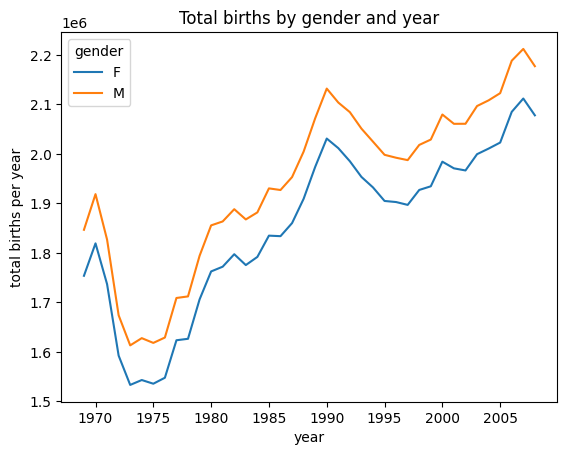

In [23]:
data_plot = births.pivot_table('births', index='year', columns='gender', aggfunc='sum')
print(data_plot)

data_plot.plot()
plt.ylabel('total births per year')
plt.title('Total births by gender and year')
plt.show()

The yearly dataset might be a little noisy, so let's take a look at the number of births per decade, which will give us a broader view.
To do so, add another column to the DataFrame which contains the decade and construct a pivot table that will provide the total number of births per decade for both males and females.

To help you create the decade information consider the operation
```Python
(x // 10) * 10
```

In [24]:

births["decade"] = 10 * (births["year"] // 10)


births.pivot_table('births', index='decade', columns='gender', aggfunc='sum')


gender,F,M
decade,,
1960,1753634,1846572
1970,16263075,17121550
1980,18310351,19243452
1990,19479454,20420553
2000,18229309,19106428


### More pivot tables

For the next exercise, we will use the following toy DataFrame:

In [25]:
df = pd.DataFrame({'foo': ['one', 'one', 'one', 'two', 'two', 'two'],
                    'bar': ['A', 'B', 'C', 'A', 'B', 'C'],
                    'baz': [1, 2, 3, 4, 5, 6],
                    'zoo': ['x', 'y', 'z', 'q', 'w', 't']})
df

,foo,bar,baz,zoo
0,one,A,1,x
1,one,B,2,y
2,one,C,3,z
3,two,A,4,q
4,two,B,5,w
5,two,C,6,t


The following pivot table operation does not specify the value on which to operate.  What did the pivot operation do in this case?  Consult the documentation of [pd.pivot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot.html) to determine that.  (Hint:  look at the help for the `values` parameter).

In [26]:
df.pivot(index='foo', columns='bar', values='baz')

bar,A,B,C
foo,,,
one,1,2,3
two,4,5,6


What this is doing is not doing a computation, rather it's taking the values from the column Baz from the data frame and creating a pivot table based on Baz's values relatative position to the index and columns. I think this question was meant for values to not have baz, so I just said what the function does. 

The following is a variant of what you just analyzed.  What is pandas doing in this case?

In [27]:
df.pivot(index='foo', columns='bar')

baz       zoo      
bar   A  B  C   A  B  C
foo                    
one   1  2  3   x  y  z
two   4  5  6   q  w  t

Since "values" and no computational expression is in the function, the following code is organizing it's result using hierarchical indexed columns, filling the rest of the pivot table with values from the two remaining columns in data frame with relativity to it's position to the index and columns from the data frame. 